In [142]:
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### ● Step:01 Select a stock (e.g., Apple, Tesla).

In [143]:
# 1. Stock select karein (Tesla = TSLA)
ticker_symbol = "TSLA"

### ● Step:02 Load historical data using the yfinance library.

In [144]:
# 2. Data download karein (Pichle 5 saal ka daily data)
# 'start' aur 'end' dates bhi de sakte hain
data = yf.download(ticker_symbol, start="2021-01-01", end="2026-03-18")

# 3. Data ka structure check karein
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
2021-01-07  272.013336  272.329987  258.399994  259.209991  154496700
2021-01-08  293.339996  294.829987  279.463318  285.333344  225166500


In [145]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1306 entries, 2021-01-04 to 2026-03-17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1306 non-null   float64
 1   (High, TSLA)    1306 non-null   float64
 2   (Low, TSLA)     1306 non-null   float64
 3   (Open, TSLA)    1306 non-null   float64
 4   (Volume, TSLA)  1306 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 61.2 KB


In [146]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1306.000000,1306.000000,1306.000000,1306.000000,1.306000e+03
mean,271.561792,277.529808,265.458507,271.695393,9.824167e+07
std,81.356958,82.939886,79.792737,81.534960,3.916685e+07
min,108.099998,111.750000,101.809998,103.000000,2.940180e+07
25%,214.005001,218.869999,208.328331,213.564167,6.902482e+07
50%,251.610001,257.258331,245.548332,251.334999,9.124705e+07
75%,323.832497,331.587502,316.749992,323.132492,1.179125e+08
max,489.880005,498.829987,485.329987,489.880005,3.065906e+08


In [147]:
data.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

In [148]:
# convert proper rows & columns like DataFrame
df = pd.DataFrame(data)
df

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000
2021-01-07,272.013336,272.329987,258.399994,259.209991,154496700
2021-01-08,293.339996,294.829987,279.463318,285.333344,225166500
...,...,...,...,...,...
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800


### ● Step:03 Use features like Open, High, Low, and Volume to predict the next Close price.

In [149]:
df['Target'] = df['Close'].shift(-1)
df.head(10)

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600,245.036667
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600,251.993332
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000,272.013336
2021-01-07,272.013336,272.329987,258.399994,259.209991,154496700,293.339996
2021-01-08,293.339996,294.829987,279.463318,285.333344,225166500,270.396667
2021-01-11,270.396667,284.809998,267.873322,283.133331,177904800,283.146667
2021-01-12,283.146667,289.333344,275.779999,277.000000,138812100,284.803345
2021-01-13,284.803345,286.823334,277.333344,284.253326,99937500,281.666656


In [150]:
df.tail(10)

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2026-03-04,405.940002,408.329987,394.579987,397.850006,68305500,405.549988
2026-03-05,405.549988,408.619995,399.420013,401.570007,51925900,396.730011
2026-03-06,396.730011,402.350006,394.209991,398.089996,64054600,398.679993
2026-03-09,398.679993,401.589996,381.399994,390.049988,67018900,399.239990
2026-03-10,399.239990,406.589996,398.190002,402.220001,59258700,407.820007
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900,395.010010
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800,391.200012
2026-03-13,391.200012,400.200012,389.950012,399.170013,58504100,395.559998


In [151]:
df = df.dropna()
df.tail(10)


Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2026-03-03,392.429993,396.339996,385.390015,395.089996,62617300,405.940002
2026-03-04,405.940002,408.329987,394.579987,397.850006,68305500,405.549988
2026-03-05,405.549988,408.619995,399.420013,401.570007,51925900,396.730011
2026-03-06,396.730011,402.350006,394.209991,398.089996,64054600,398.679993
2026-03-09,398.679993,401.589996,381.399994,390.049988,67018900,399.239990
2026-03-10,399.239990,406.589996,398.190002,402.220001,59258700,407.820007
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900,395.010010
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800,391.200012


### Create two variables

In [152]:
# input features
X = df[['Close', 'High', 'Low', 'Open', 'Volume']]

# Target/Prediction
y = df['Target']

### Train-Test Split

In [153]:
x_train , x_test , y_train , y_test = train_test_split(X,y , test_size=0.2 , random_state=42)

### ● Step:04 Train a Linear Regression or Random Forest model.

In [154]:
model = LinearRegression().fit(x_train , y_train)
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [158]:
y_train_predict = model.predict(X)
y_train_predict

array([244.35422722, 244.99026085, 253.22533379, ..., 395.30294618,
       391.17853773, 395.55061085], shape=(1305,))

In [ ]:
y_test_predict = model.predict(x_test)
y_test_predict

array([244.35422722, 244.99026085, 253.22533379, ..., 395.30294618,
       391.17853773, 395.55061085], shape=(1305,))

In [162]:
from sklearn.metrics import r2_score
print(r2_score(y_test , y_test_predict))

0.9863544775145813


### ● Step:05 Plot actual vs predicted closing prices for comparison.

<Axes: xlabel='Target'>

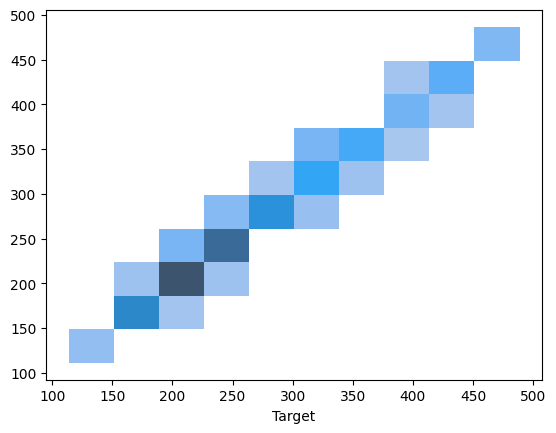

In [167]:
import seaborn as sns
sns.histplot(x= y_test , y = y_test_predict)